# Linkography Code Annotation Implementation

## TRY: Detect ONE linkography pattern using ONE or TWO annotation codes

Remember, these sessions' JSON files were split into 10 minute segments. Might have to fix this again if we are to scale implementation etc.

## Iteration 1

In [7]:
import json
from pathlib import Path

# --------------------------------------------------------
# 1. Load the JSON file
# --------------------------------------------------------
file_path = Path("/Users/maxchalekson/Desktop/gemini_data_analysis/data/2021ABI/session_data/2021_05_21_ABI_S4.json")

with open(file_path, "r") as f:
    data = json.load(f)

print("Top-level keys:", data.keys())

# --------------------------------------------------------
# 2. Normalize to utterance list
# --------------------------------------------------------
# In this file, utterances live inside "all_data"
raw_utts = data["all_data"]

print("Number of utterances:", len(raw_utts))
print("Example utterance keys:", raw_utts[0].keys())

# --------------------------------------------------------
# 3. Extract the fields we need
#    (use index as a fallback utterance_id)
# --------------------------------------------------------
utterances = []
for i, u in enumerate(raw_utts):
    utterances.append({
        "utterance_id": u.get("utterance_id", f"utt_{i}"),
        "speaker": u.get("speaker"),
        "timestamp": u.get("timestamp"),   # could be None here; that's fine for now
        "annotations": u.get("annotations", {}) or {},
        "transcript": u.get("transcript", "")
    })

# Quick sanity check: how many have non-empty annotations?
non_empty = sum(1 for u in utterances if u["annotations"])
print("Utterances with non-empty annotations:", non_empty)

# Show a couple of examples so you can eyeball them
for u in utterances[:3]:
    print("\n--- Example utterance ---")
    print("utterance_id:", u["utterance_id"])
    print("speaker:", u["speaker"])
    print("timestamp:", u["timestamp"])
    print("annotations keys:", list(u["annotations"].keys()))
    print("snippet:", u["transcript"][:120])


# --------------------------------------------------------
# 4. Define heuristic for “short-span forelink”
#    We treat certain annotation categories as "builds on / responds to"
#    and link each such utterance to the *immediately previous* one.
# --------------------------------------------------------
def detect_short_span_forelinks(utterances):
    links = []

    # Categories that usually indicate a move that builds on
    # or responds to prior talk (you can tweak this set)
    build_categories = [
        "Knowledge Sharing",
        "Coordination and Decision Practices",
        "Participation Dynamics",
        "Communication Practices",
        "Goal/Focus Clarity",
        "Trust and Psychological Safety",
        "Conflict Management"
    ]

    for i in range(1, len(utterances)):
        prev_u = utterances[i - 1]
        curr_u = utterances[i]

        ann_curr = curr_u.get("annotations", {}) or {}

        # If the current utterance has *any* of these categories,
        # treat it as a short-span forelink from previous → current
        if any(cat in ann_curr for cat in build_categories):
            links.append({
                "from": prev_u["utterance_id"],
                "to": curr_u["utterance_id"],
                "type": "short_span_forelink",
                "speaker_from": prev_u["speaker"],
                "speaker_to": curr_u["speaker"],
                "categories_curr": list(ann_curr.keys()),
                "snippet_prev": (prev_u.get("transcript") or "")[:120],
                "snippet_curr": (curr_u.get("transcript") or "")[:120],
            })

    return links


# --------------------------------------------------------
# 5. Run detection and inspect a few links
# --------------------------------------------------------
links_found = detect_short_span_forelinks(utterances)

print(f"\nDetected {len(links_found)} short-span forelinks.")
for link in links_found[:10]:
    print("\n--- Forelink ---")
    for k, v in link.items():
        print(f"{k}: {v}")

Top-level keys: dict_keys(['all_speakers', 'total_speaking_length', 'all_data'])
Number of utterances: 259
Example utterance keys: dict_keys(['speaker', 'timestamp', 'transcript', 'speaking_duration', 'nods_others', 'smile_self', 'smile_other', 'distracted_others', 'hand_gesture', 'interuption', 'overlap', 'screenshare', 'screenshare_content', 'start_time', 'end_time', 'annotations', 'role', 'when'])
Utterances with non-empty annotations: 259

--- Example utterance ---
utterance_id: utt_0
speaker: Anna Moore
timestamp: 00:00-00:23
annotations keys: ['Coordination and Decision Practices', 'Information Seeking']
snippet: suggest is that we very quickly introduce ourselves um and then we'll start working on generating ideas. So is there any

--- Example utterance ---
utterance_id: utt_1
speaker: Anna Moore
timestamp: 00:23-01:57
annotations keys: ['Knowledge Sharing', 'Coordination and Decision Practices']
snippet: So I thought I thought we all first facilitators introduce themselves. But

## Iteration 2

In [8]:
import json
from pathlib import Path

# --------------------------------------------------------
# 1. Load the JSON file.  2021-05-21-ABI-S4
# --------------------------------------------------------
file_path = Path("/Users/maxchalekson/Desktop/gemini_data_analysis/data/2021ABI/session_data/2021_05_21_ABI_S4.json")

with open(file_path, "r") as f:
    data = json.load(f)

print("Top-level keys:", data.keys())

# --------------------------------------------------------
# 2. Normalize to utterance list
# --------------------------------------------------------
raw_utts = data["all_data"]

print("Number of utterances:", len(raw_utts))
print("Example utterance keys:", raw_utts[0].keys())

# --------------------------------------------------------
# 3. Extract the fields we need
# --------------------------------------------------------
utterances = []
for i, u in enumerate(raw_utts):
    utterances.append({
        "utterance_id": u.get("utterance_id", f"utt_{i}"),
        "speaker": u.get("speaker"),
        "timestamp": u.get("timestamp"),
        "annotations": u.get("annotations", {}) or {},
        "transcript": u.get("transcript", "")
    })

non_empty = sum(1 for u in utterances if u["annotations"])
print("Utterances with non-empty annotations:", non_empty)

# --------------------------------------------------------
# 4. Helper: does this utterance look "idea-building"?
# --------------------------------------------------------
IDEA_CODES = {
    "Idea Management",
    "Knowledge Sharing",
    "Evaluation Practices",
    "Integration Practices",
}

def is_idea_building(ann_dict):
    """
    ann_dict: {"CodeName": {"explanation": ..., "score": ..., "when": ...}, ...}
    Returns True if the utterance has at least one idea-related code
    that is NOT just an intro / "beginning" meta move.
    """
    for code, info in ann_dict.items():
        if code in IDEA_CODES:
            when = (info or {}).get("when", "").lower()
            if when != "beginning":   # exclude introductions
                return True
    return False

# --------------------------------------------------------
# 5. Detect short-span forelinks *only for idea-building moves*
# --------------------------------------------------------
def detect_short_span_forelinks_v2(utterances):
    links = []

    for i in range(1, len(utterances)):
        prev_u = utterances[i - 1]
        curr_u = utterances[i]

        ann_curr = curr_u.get("annotations", {}) or {}

        # New heuristic: only link if current utterance is "idea-building"
        if is_idea_building(ann_curr):
            links.append({
                "from": prev_u["utterance_id"],
                "to": curr_u["utterance_id"],
                "type": "short_span_forelink_v2",
                "speaker_from": prev_u["speaker"],
                "speaker_to": curr_u["speaker"],
                "timestamp_curr": curr_u["timestamp"],
                "codes_curr": list(ann_curr.keys()),
                "snippet_prev": (prev_u.get("transcript") or "")[:120],
                "snippet_curr": (curr_u.get("transcript") or "")[:120],
            })

    return links

# --------------------------------------------------------
# 6. Run detection and compare
# --------------------------------------------------------
links_v2 = detect_short_span_forelinks_v2(utterances)

print(f"\nIteration 2: detected {len(links_v2)} idea-building short-span forelinks.")
for link in links_v2[:10]:
    print("\n--- Forelink v2 ---")
    for k, v in link.items():
        print(f"{k}: {v}")

Top-level keys: dict_keys(['all_speakers', 'total_speaking_length', 'all_data'])
Number of utterances: 259
Example utterance keys: dict_keys(['speaker', 'timestamp', 'transcript', 'speaking_duration', 'nods_others', 'smile_self', 'smile_other', 'distracted_others', 'hand_gesture', 'interuption', 'overlap', 'screenshare', 'screenshare_content', 'start_time', 'end_time', 'annotations', 'role', 'when'])
Utterances with non-empty annotations: 259

Iteration 2: detected 127 idea-building short-span forelinks.

--- Forelink v2 ---
from: utt_67
to: utt_68
type: short_span_forelink_v2
speaker_from: Benjamin Bartelle
speaker_to: Benjamin Bartelle
timestamp_curr: 06:09-07:08
codes_curr: ['Knowledge Sharing', 'Information Seeking', 'Relational Climate']
snippet_prev: I think some of us are you can study people though, right?
snippet_curr: Um Molly, you study people, but what you get is not mechanistic per se. It's like a convolution of the mechanisms. And s

--- Forelink v2 ---
from: utt_68
to: u

# Stopping the Iteration Implementation. Now Reflecting on it all

# Code Sequences, Couplets & Triplets

Stay with the current annotation codes

Build sequences ("couplets") with temporal info

Summarize per session (this is in a table output)
- How often each code appears
- How often each transition (pair) appears
- Where (beginning/middle/end) those transitions show up

**reminder: also need to handle the 10 minute chunks**

In [17]:
import os
import json
import pandas as pd
import numpy as np

# ----------------------------------------------------
# 0. CONFIG
# ----------------------------------------------------
# Change this to the root folder that contains
# 2020NES, 2021SLU, 2021NES, 2021MZT, etc.
# e.g., BASE_DIR = "/Users/maxchalekson/Desktop/gemini_data_analysis/data/v2-data"
BASE_DIR = "/Users/maxchalekson/Desktop/gemini_data_analysis/data"

# Map the human-readable code labels (in JSON) to safe column names
CODE_MAP = {
    "Idea Management": "Idea_Management",
    "Information Seeking": "Information_Seeking",
    "Knowledge Sharing": "Knowledge_Sharing",
    "Evaluation Practices": "Evaluation_Practices",
    "Relational Climate": "Relational_Climate",
    "Participation Dynamics": "Participation_Dynamics",
    "Coordination and Decision Practices": "Coordination_and_Decision_Practices",
    "Integration Practices": "Integration_Practices",
}

CODE_LABELS = list(CODE_MAP.keys())
CODE_COLS   = list(CODE_MAP.values())


# ----------------------------------------------------
# 1. Small helpers: time + region
# ----------------------------------------------------
def parse_hhmmss_to_sec(t):
    """
    t like '00:00' or '01:23:45'.
    Returns seconds as int. If bad format, returns np.nan.
    """
    if not isinstance(t, str) or not t.strip():
        return np.nan
    parts = t.strip().split(":")
    try:
        parts = [int(p) for p in parts]
    except ValueError:
        return np.nan

    if len(parts) == 2:  # mm:ss
        mm, ss = parts
        return mm * 60 + ss
    elif len(parts) == 3:  # hh:mm:ss
        hh, mm, ss = parts
        return hh * 3600 + mm * 60 + ss
    else:
        return np.nan


def assign_region_for_session(df_session):
    """
    Given a single-session DataFrame with 'mid_sec', add 'region' 
    (Beginning / Middle / End) based on thirds of the time.
    """
    max_t = df_session["mid_sec"].max()
    if pd.isna(max_t) or max_t <= 0:
        # default everything to Middle if we don't have good timing
        df_session["region"] = "Middle"
        return df_session

    b_cut = max_t / 3.0
    m_cut = 2.0 * max_t / 3.0

    def _region(m):
        if m < b_cut:
            return "Beginning"
        elif m < m_cut:
            return "Middle"
        else:
            return "End"

    df_session["region"] = df_session["mid_sec"].apply(_region)
    return df_session


# ----------------------------------------------------
# 2. Flatten a single JSON session file
# ----------------------------------------------------
def flatten_session_json(json_path):
    """
    Read one SCIALOG-style JSON:
      {
        "all_speakers": [...],
        "total_speaking_length": ...,
        "all_data": [
           {
             "speaker": ...,
             "timestamp": "00:00-00:38",
             "start_time": "00:00",
             "end_time": "00:38",
             "annotations": {
                 "Idea Management": {"score": 2, "when": "middle", ...},
                 ...
             },
             ...
           },
           ...
        ]
      }
    Return a list of dict rows (one per utterance).
    """
    try:
        with open(json_path, "r") as f:
            data = json.load(f)
    except Exception as e:
        print(f"[WARN] Failed to load {json_path}: {e}")
        return []

    # figure out conference + session IDs
    # .../2021SLU/session_data/2021_06_11_SLU_S3.json
    session_filename = os.path.basename(json_path)
    session_id = os.path.splitext(session_filename)[0]
    conference = os.path.basename(os.path.dirname(os.path.dirname(json_path)))

    # determine where utterances are stored
    if isinstance(data, dict):
        all_data = data.get("all_data", [])
    elif isinstance(data, list):
        all_data = data
    else:
        all_data = []

    if not all_data:
        print(f"[WARN] Skipping {json_path} — empty or missing all_data.")
        return []

    rows = []
    for entry in all_data:
        if not isinstance(entry, dict):
            continue

        speaker = entry.get("speaker")
        timestamp_raw = entry.get("timestamp")
        start_time = entry.get("start_time")
        end_time = entry.get("end_time")

        # If start_time / end_time missing, try parsing from timestamp
        if (not start_time or not end_time) and isinstance(timestamp_raw, str) and "-" in timestamp_raw:
            start_raw, end_raw = timestamp_raw.split("-", 1)
            start_time = start_time or start_raw.strip()
            end_time = end_time or end_raw.strip()

        start_sec = parse_hhmmss_to_sec(start_time)
        end_sec   = parse_hhmmss_to_sec(end_time)
        if pd.isna(start_sec) or pd.isna(end_sec):
            mid_sec = np.nan
        else:
            mid_sec = (start_sec + end_sec) / 2.0

        # Screenshare / gesture at top level
        screenshare = entry.get("screenshare")
        hand_gesture = entry.get("hand_gesture")

        # Annotations dict
        annotations = entry.get("annotations") or {}

        row = {
            "conference": conference,
            "session": session_id,
            "speaker": speaker,
            "timestamp_raw": timestamp_raw,
            "start_time": start_time,
            "end_time": end_time,
            "start_sec": start_sec,
            "end_sec": end_sec,
            "mid_sec": mid_sec,
            "speaking_duration": entry.get("speaking_duration"),
            "screenshare": screenshare,
            "hand_gesture": hand_gesture,
            # keep raw annotations for debugging
            "annotations_raw": annotations,
        }

        # For each of the 8 codes, create a 0/1 presence flag from "score"
        for label, colname in CODE_MAP.items():
            ann = annotations.get(label, {})
            present = 0
            if isinstance(ann, dict):
                score = ann.get("score", None)
                if score is not None and score != "" and not pd.isna(score):
                    try:
                        present = int(float(score) > 0)
                    except Exception:
                        # fallback: if score is set at all, consider it present
                        present = 1
            row[colname] = present

        rows.append(row)

    return rows


# ----------------------------------------------------
# 3. Build df_events over all conferences / sessions
# ----------------------------------------------------
all_rows = []

for conf_dir in sorted(os.listdir(BASE_DIR)):
    conf_path = os.path.join(BASE_DIR, conf_dir)
    if not os.path.isdir(conf_path):
        continue

    session_dir = os.path.join(conf_path, "session_data")
    if not os.path.isdir(session_dir):
        continue

    for fname in sorted(os.listdir(session_dir)):
        if not fname.endswith(".json"):
            continue
        fpath = os.path.join(session_dir, fname)
        rows = flatten_session_json(fpath)
        all_rows.extend(rows)

df_events = pd.DataFrame(all_rows)
print("df_events shape:", df_events.shape)
print("Columns:", df_events.columns.tolist())

# ----------------------------------------------------
# 3a. Add region + minute columns
# ----------------------------------------------------
# Region assignment (Beginning/Middle/End) per session
df_regions = []
for (conf, sess), sub in df_events.groupby(["conference", "session"], sort=False):
    sub_copy = sub.copy()
    sub_copy = assign_region_for_session(sub_copy)
    df_regions.append(sub_copy)

df_events = pd.concat(df_regions, ignore_index=True)

# Minute-level time (integer minute from start)
df_events["start_minute"] = (df_events["start_sec"] // 60).fillna(-1).astype(int)
df_events["end_minute"]   = (df_events["end_sec"]   // 60).fillna(-1).astype(int)
df_events["mid_minute"]   = (df_events["mid_sec"]   // 60).fillna(-1).astype(int)

print("Region counts:")
print(df_events["region"].value_counts(dropna=False))


# ----------------------------------------------------
# 4. Session-level summary features
# ----------------------------------------------------
# Basic session stats
session_group = df_events.groupby(["conference", "session"], as_index=False)

df_session_features = session_group.agg(
    n_utterances=("speaker", "size"),
    n_speakers=("speaker", pd.Series.nunique),
    max_time=("end_sec", "max"),
)

# Region distribution per session
region_counts = (
    df_events
    .groupby(["conference", "session", "region"])
    .size()
    .reset_index(name="region_count")
)

region_pivot = region_counts.pivot(
    index=["conference", "session"],
    columns="region",
    values="region_count"
).fillna(0)

for r in ["Beginning", "Middle", "End"]:
    if r not in region_pivot.columns:
        region_pivot[r] = 0

region_pivot = region_pivot[["Beginning", "Middle", "End"]].reset_index()

# Code counts per session (how many utterances had each code present)
code_counts = (
    df_events
    .groupby(["conference", "session"])[CODE_COLS]
    .sum()
    .reset_index()
)

# Merge all session-level features
df_session_features = (
    df_session_features
    .merge(region_pivot, on=["conference", "session"], how="left")
    .merge(code_counts, on=["conference", "session"], how="left")
)

df_session_features[CODE_COLS] = df_session_features[CODE_COLS].fillna(0).astype(int)

print("df_session_features shape:", df_session_features.shape)
print(df_session_features.head())


# ----------------------------------------------------
# 5. Build code couplets (transitions) per session
# ----------------------------------------------------
# First, filter utterances that have at least one active code
df_events["any_code"] = df_events[CODE_COLS].sum(axis=1) > 0
print("Rows with any active code:", df_events["any_code"].sum(), "out of", len(df_events))

active = df_events[df_events["any_code"]].copy()

if active.empty:
    print("No active-coded utterances were found — couplets will be empty for now.")
    df_couplets = pd.DataFrame()
else:
    # Sort by time within each session
    active = active.sort_values(["conference", "session", "start_sec"]).reset_index(drop=True)

    records = []
    for (conf, sess), sub in active.groupby(["conference", "session"], sort=False):
        prev_codes = None
        prev_region = None
        prev_time = None

        for _, row in sub.iterrows():
            # which codes are active in this utterance?
            this_codes = [c for c in CODE_COLS if row[c] == 1]
            if not this_codes:
                continue

            if prev_codes is not None:
                # create all pair-wise transitions prev_code -> this_code
                for from_code in prev_codes:
                    for to_code in this_codes:
                        records.append({
                            "conference": conf,
                            "session": sess,
                            "from_code": from_code,
                            "to_code": to_code,
                            "from_region": prev_region,
                            "to_region": row["region"],
                            "from_time": prev_time,
                            "to_time": row["start_sec"],
                        })

            # update "previous" pointer
            prev_codes = this_codes
            prev_region = row["region"]
            prev_time = row["start_sec"]

    df_couplets = pd.DataFrame(records)

print("df_couplets shape:", df_couplets.shape)
print(df_couplets.head())


# ----------------------------------------------------
# 6. Aggregate couplet features (for model / viz)
# ----------------------------------------------------
if not df_couplets.empty:
    # Add minute-level for couplets
    df_couplets["from_minute"] = (df_couplets["from_time"] // 60).fillna(-1).astype(int)
    df_couplets["to_minute"]   = (df_couplets["to_time"]   // 60).fillna(-1).astype(int)

    # Overall couplet counts per session
    df_couplet_counts = (
        df_couplets
        .groupby(["conference", "session", "from_code", "to_code"])
        .size()
        .reset_index(name="n_couplets")
    )

    print("df_couplet_counts sample:")
    print(df_couplet_counts.head())

    # Couplets by region of origin (Beginning/Middle/End)
    df_couplet_region = (
        df_couplets
        .groupby(["conference", "session", "from_region", "from_code", "to_code"])
        .size()
        .reset_index(name="n_couplets_region")
    )

    print("df_couplet_region sample:")
    print(df_couplet_region.head())
else:
    df_couplet_counts = pd.DataFrame()
    df_couplet_region = pd.DataFrame()
    print("No couplet aggregates computed because df_couplets is empty.")


# ----------------------------------------------------
# 7. Minute-level code distribution (per session)
# ----------------------------------------------------
# Long-form table: how many times each code is active in each minute
minute_code_table = (
    df_events
    .melt(
        id_vars=["conference", "session", "mid_minute"],
        value_vars=CODE_COLS,
        var_name="code",
        value_name="active"
    )
    .query("active == 1")
    .groupby(["conference", "session", "mid_minute", "code"])
    .size()
    .reset_index(name="n_events")
)

print("minute_code_table shape:", minute_code_table.shape)
print(minute_code_table.head())


# ----------------------------------------------------
# 8. Minute-level couplet distribution
# ----------------------------------------------------
if not df_couplets.empty:
    minute_couplets = (
        df_couplets
        .groupby(["conference", "session", "from_minute", "from_code", "to_code"])
        .size()
        .reset_index(name="n_couplets")
    )
    print("minute_couplets shape:", minute_couplets.shape)
    print(minute_couplets.head())
else:
    minute_couplets = pd.DataFrame()
    print("minute_couplets is empty because df_couplets is empty.")

df_events shape: (30558, 21)
Columns: ['conference', 'session', 'speaker', 'timestamp_raw', 'start_time', 'end_time', 'start_sec', 'end_sec', 'mid_sec', 'speaking_duration', 'screenshare', 'hand_gesture', 'annotations_raw', 'Idea_Management', 'Information_Seeking', 'Knowledge_Sharing', 'Evaluation_Practices', 'Relational_Climate', 'Participation_Dynamics', 'Coordination_and_Decision_Practices', 'Integration_Practices']
Region counts:
region
End          11644
Beginning    10054
Middle        8860
Name: count, dtype: int64
df_session_features shape: (157, 16)
  conference            session  n_utterances  n_speakers  max_time  \
0    2020NES  2020_11_05_NES_S1            82          12      3120   
1    2020NES  2020_11_05_NES_S2            67          11      3596   
2    2020NES  2020_11_05_NES_S3            45          10      3095   
3    2020NES  2020_11_05_NES_S4            41           9      3073   
4    2020NES  2020_11_05_NES_S5            28          11      3063   

   Begin

## Isolating 2021_05_21_ABI_S4

In [24]:
# ----------------------------------------------
# FILTER ONE SESSION: 2021_05_21_ABI_S4
# ----------------------------------------------
SESSION_ID = "2021_05_21_ABI_S4"
CONF_ID    = "2021ABI"   # conference folder name

events_s4 = df_events[
    (df_events["conference"] == CONF_ID) &
    (df_events["session"] == SESSION_ID)
].copy()

couplets_s4 = df_couplets[
    (df_couplets["conference"] == CONF_ID) &
    (df_couplets["session"] == SESSION_ID)
].copy()

minute_codes_s4 = minute_code_table[
    (minute_code_table["conference"] == CONF_ID) &
    (minute_code_table["session"] == SESSION_ID)
].copy()

minute_couplets_s4 = minute_couplets[
    (minute_couplets["conference"] == CONF_ID) &
    (minute_couplets["session"] == SESSION_ID)
].copy()

session_feat_s4 = df_session_features[
    (df_session_features["conference"] == CONF_ID) &
    (df_session_features["session"] == SESSION_ID)
].copy()

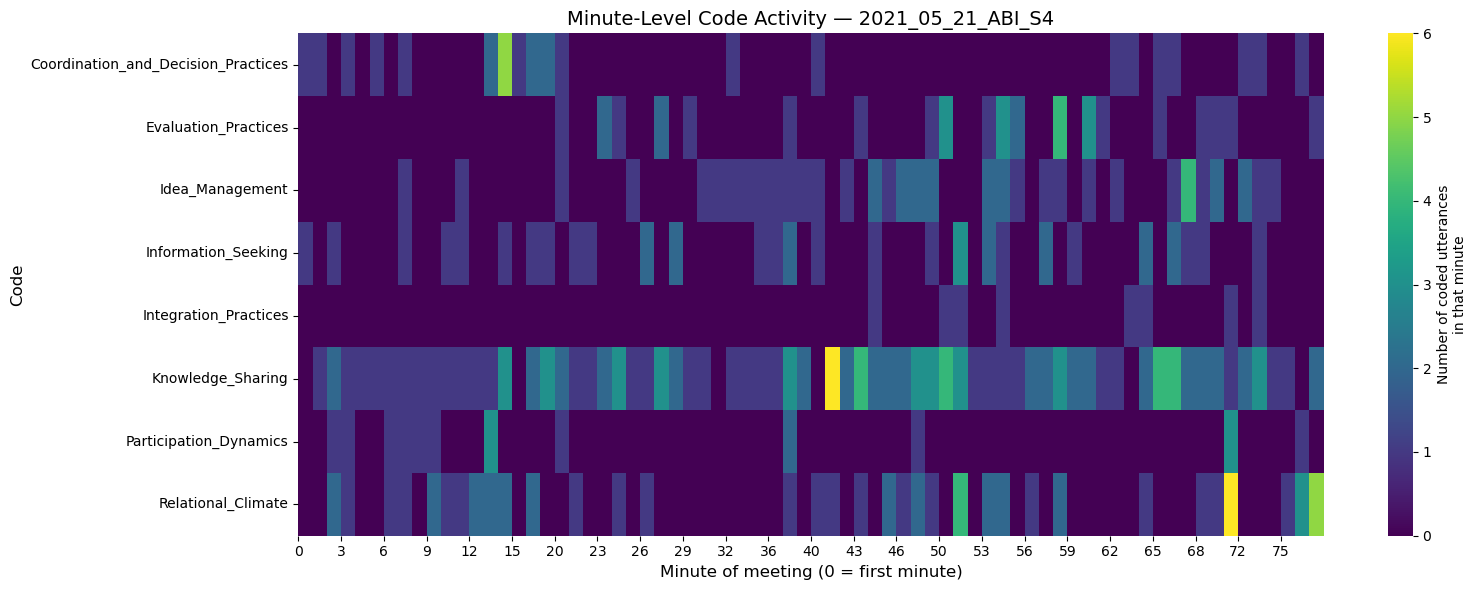

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

# Pivot: rows = codes, columns = minute index, values = count of coded utterances
heat_df = (
    minute_codes_s4
    .pivot(index="code", columns="mid_minute", values="n_events")
    .fillna(0)
)

# Make sure minutes are in order
heat_df = heat_df.reindex(sorted(heat_df.columns), axis=1)

plt.figure(figsize=(16, 6))
ax = sns.heatmap(
    heat_df,
    cmap="viridis",
    cbar_kws={"label": "Number of coded utterances\nin that minute"}
)

ax.set_title("Minute-Level Code Activity — 2021_05_21_ABI_S4", fontsize=14)
ax.set_ylabel("Code", fontsize=12)
ax.set_xlabel("Minute of meeting (0 = first minute)", fontsize=12)

# show x-ticks every 2–3 minutes to avoid clutter (tweak as needed)
xticks = sorted(heat_df.columns)
ax.set_xticks(range(0, len(xticks), 3))
ax.set_xticklabels(xticks[0::3])

plt.tight_layout()
plt.show()

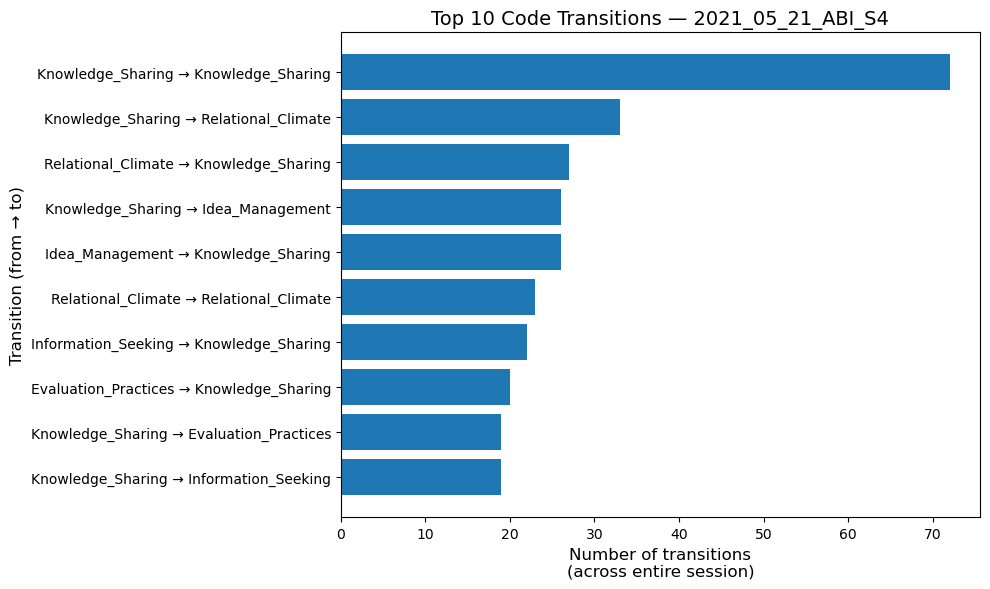

,from_code,to_code,n,pair_label
43,Knowledge_Sharing,Knowledge_Sharing,72,Knowledge_Sharing → Knowledge_Sharing
45,Knowledge_Sharing,Relational_Climate,33,Knowledge_Sharing → Relational_Climate
59,Relational_Climate,Knowledge_Sharing,27,Relational_Climate → Knowledge_Sharing
40,Knowledge_Sharing,Idea_Management,26,Knowledge_Sharing → Idea_Management
21,Idea_Management,Knowledge_Sharing,26,Idea_Management → Knowledge_Sharing
61,Relational_Climate,Relational_Climate,23,Relational_Climate → Relational_Climate
28,Information_Seeking,Knowledge_Sharing,22,Information_Seeking → Knowledge_Sharing
13,Evaluation_Practices,Knowledge_Sharing,20,Evaluation_Practices → Knowledge_Sharing
39,Knowledge_Sharing,Evaluation_Practices,19,Knowledge_Sharing → Evaluation_Practices
41,Knowledge_Sharing,Information_Seeking,19,Knowledge_Sharing → Information_Seeking


In [27]:
# Count transitions across the **entire session** (not per minute)
top_couplets = (
    couplets_s4
    .groupby(["from_code", "to_code"])
    .size()
    .reset_index(name="n")
    .sort_values("n", ascending=False)
    .head(10)
)

# Combine into a single label like "KS → RC"
top_couplets["pair_label"] = (
    top_couplets["from_code"] + " → " + top_couplets["to_code"]
)

plt.figure(figsize=(10, 6))
plt.barh(top_couplets["pair_label"], top_couplets["n"])
plt.gca().invert_yaxis()  # biggest on top

plt.title("Top 10 Code Transitions — 2021_05_21_ABI_S4", fontsize=14)
plt.xlabel("Number of transitions\n(across entire session)", fontsize=12)
plt.ylabel("Transition (from → to)", fontsize=12)

plt.tight_layout()
plt.show()

top_couplets  # optional: print the table as well

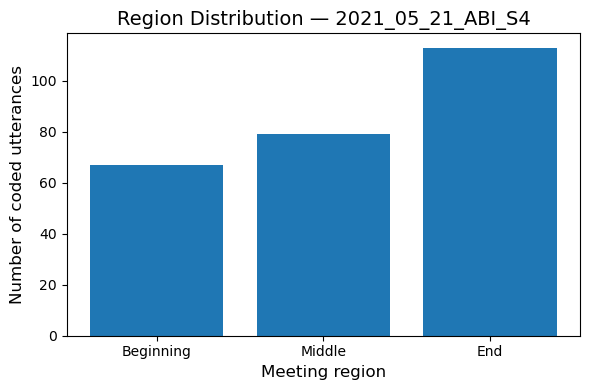

In [30]:
region_vals = session_feat_s4[["Beginning", "Middle", "End"]].iloc[0]

plt.figure(figsize=(6, 4))
plt.bar(region_vals.index, region_vals.values)

plt.title("Region Distribution — 2021_05_21_ABI_S4", fontsize=14)
plt.xlabel("Meeting region", fontsize=12)
plt.ylabel("Number of coded utterances", fontsize=12)


plt.tight_layout()
plt.show()

# Examining the Knowledge Sharing Sequences

In [31]:
import numpy as np
import pandas as pd

# -------------------------------------------------------------------
# STEP 1: Knowledge-Sharing sequences (streaks, regions, timing)
# -------------------------------------------------------------------

def compute_ks_sequence_features(df_events, ks_col="Knowledge_Sharing"):
    """
    For each (conference, session):
      - KS_total_utterances
      - KS_streak_count  (number of distinct runs of consecutive KS utterances)
      - KS_max_streak_len
      - KS_mean_streak_len
      - KS_beginning / KS_middle / KS_end counts
      - KS_first_minute, KS_last_minute, KS_mean_minute  (midpoint of KS utterances)
    Returns: DataFrame indexed by (conference, session).
    """
    rows = []

    # make sure region exists (you already computed it earlier)
    if "region" not in df_events.columns:
        raise ValueError("df_events is missing 'region' column. "
                         "Make sure you ran the region assignment step first.")

    for (conf, sess), sub in df_events.groupby(["conference", "session"], sort=False):
        sub = sub.sort_values("start_sec").reset_index(drop=True)

        # Basic KS presence
        ks_mask = sub[ks_col] == 1
        KS_total_utterances = int(ks_mask.sum())

        # If no KS at all, fill zeros and continue
        if KS_total_utterances == 0:
            rows.append({
                "conference": conf,
                "session": sess,
                "KS_total_utterances": 0,
                "KS_streak_count": 0,
                "KS_max_streak_len": 0,
                "KS_mean_streak_len": 0.0,
                "KS_beginning": 0,
                "KS_middle": 0,
                "KS_end": 0,
                "KS_first_minute": np.nan,
                "KS_last_minute": np.nan,
                "KS_mean_minute": np.nan,
            })
            continue

        # ---- Streaks of consecutive KS utterances ----
        streak_lengths = []
        in_streak = False
        cur_len = 0

        for is_ks in ks_mask:
            if is_ks:
                if not in_streak:
                    in_streak = True
                    cur_len = 1
                else:
                    cur_len += 1
            else:
                if in_streak:
                    streak_lengths.append(cur_len)
                    in_streak = False
                    cur_len = 0

        # close final streak
        if in_streak:
            streak_lengths.append(cur_len)

        KS_streak_count = len(streak_lengths)
        KS_max_streak_len = int(max(streak_lengths)) if streak_lengths else 0
        KS_mean_streak_len = float(np.mean(streak_lengths)) if streak_lengths else 0.0

        # ---- Region distribution of KS ----
        ks_region_counts = (
            sub.loc[ks_mask, "region"]
            .value_counts()
            .to_dict()
        )
        KS_beginning = int(ks_region_counts.get("Beginning", 0))
        KS_middle    = int(ks_region_counts.get("Middle", 0))
        KS_end       = int(ks_region_counts.get("End", 0))

        # ---- Timing of KS in minutes (using mid_sec) ----
        ks_times_sec = sub.loc[ks_mask, "mid_sec"].dropna().values
        if len(ks_times_sec) > 0:
            ks_minutes = ks_times_sec / 60.0
            KS_first_minute = float(np.min(ks_minutes))
            KS_last_minute  = float(np.max(ks_minutes))
            KS_mean_minute  = float(np.mean(ks_minutes))
        else:
            KS_first_minute = KS_last_minute = KS_mean_minute = np.nan

        rows.append({
            "conference": conf,
            "session": sess,
            "KS_total_utterances": KS_total_utterances,
            "KS_streak_count": KS_streak_count,
            "KS_max_streak_len": KS_max_streak_len,
            "KS_mean_streak_len": KS_mean_streak_len,
            "KS_beginning": KS_beginning,
            "KS_middle": KS_middle,
            "KS_end": KS_end,
            "KS_first_minute": KS_first_minute,
            "KS_last_minute": KS_last_minute,
            "KS_mean_minute": KS_mean_minute,
        })

    df_ks_features = pd.DataFrame(rows)
    return df_ks_features


df_ks_features = compute_ks_sequence_features(df_events, ks_col="Knowledge_Sharing")
print("df_ks_features shape:", df_ks_features.shape)
print(df_ks_features.head())

# -------------------------------------------------------------------
# STEP 2: Proto-linkography metrics from code couplets
# -------------------------------------------------------------------

def compute_linkography_features(df_couplets):
    """
    For each (conference, session), compute:
      - n_transitions
      - n_unique_pairs
      - transition_entropy (Shannon)
      - key KS-related transitions:
          KS->KS
          KS->Idea_Management
          Idea_Management->KS
          KS->Evaluation_Practices
          Evaluation_Practices->KS
          KS->Information_Seeking
          Information_Seeking->KS
          KS->Relational_Climate
          Relational_Climate->KS
    Returns: DataFrame indexed by (conference, session).
    """
    if df_couplets is None or df_couplets.empty:
        print("df_couplets is empty; returning empty linkography feature frame.")
        return pd.DataFrame(columns=[
            "conference", "session",
            "n_transitions", "n_unique_pairs", "transition_entropy",
            "KS_to_KS", "KS_to_Idea", "Idea_to_KS",
            "KS_to_Eval", "Eval_to_KS",
            "KS_to_Info", "Info_to_KS",
            "KS_to_Rel", "Rel_to_KS",
        ])

    rows = []
    for (conf, sess), sub in df_couplets.groupby(["conference", "session"], sort=False):
        n_transitions = len(sub)

        # pair counts
        pair_counts = sub.groupby(["from_code", "to_code"]).size()
        n_unique_pairs = len(pair_counts)

        # entropy of transition distribution
        probs = pair_counts / n_transitions
        transition_entropy = float(-(probs * np.log2(probs)).sum()) if n_transitions > 0 else 0.0

        # Helper to count specific patterns
        def count_pairs(f, t):
            return int(((sub["from_code"] == f) & (sub["to_code"] == t)).sum())

        KS  = "Knowledge_Sharing"
        IM  = "Idea_Management"
        EV  = "Evaluation_Practices"
        IS  = "Information_Seeking"
        RC  = "Relational_Climate"

        KS_to_KS   = count_pairs(KS, KS)
        KS_to_Idea = count_pairs(KS, IM)
        Idea_to_KS = count_pairs(IM, KS)

        KS_to_Eval = count_pairs(KS, EV)
        Eval_to_KS = count_pairs(EV, KS)

        KS_to_Info = count_pairs(KS, IS)
        Info_to_KS = count_pairs(IS, KS)

        KS_to_Rel  = count_pairs(KS, RC)
        Rel_to_KS  = count_pairs(RC, KS)

        rows.append({
            "conference": conf,
            "session": sess,
            "n_transitions": n_transitions,
            "n_unique_pairs": n_unique_pairs,
            "transition_entropy": transition_entropy,
            "KS_to_KS": KS_to_KS,
            "KS_to_Idea": KS_to_Idea,
            "Idea_to_KS": Idea_to_KS,
            "KS_to_Eval": KS_to_Eval,
            "Eval_to_KS": Eval_to_KS,
            "KS_to_Info": KS_to_Info,
            "Info_to_KS": Info_to_KS,
            "KS_to_Rel": KS_to_Rel,
            "Rel_to_KS": Rel_to_KS,
        })

    df_linko = pd.DataFrame(rows)
    return df_linko


df_linko_features = compute_linkography_features(df_couplets)
print("df_linko_features shape:", df_linko_features.shape)
print(df_linko_features.head())

# -------------------------------------------------------------------
# STEP 3: Merge session features + KS sequences + linkography metrics
# -------------------------------------------------------------------

df_session_linkography = (
    df_session_features
    .merge(df_ks_features, on=["conference", "session"], how="left")
    .merge(df_linko_features, on=["conference", "session"], how="left")
)

# Fill NaNs for integer-ish linkography counts with 0
count_cols = [
    "KS_total_utterances", "KS_streak_count", "KS_max_streak_len",
    "KS_beginning", "KS_middle", "KS_end",
    "n_transitions", "n_unique_pairs",
    "KS_to_KS", "KS_to_Idea", "Idea_to_KS",
    "KS_to_Eval", "Eval_to_KS",
    "KS_to_Info", "Info_to_KS",
    "KS_to_Rel", "Rel_to_KS",
]
for c in count_cols:
    if c in df_session_linkography.columns:
        df_session_linkography[c] = df_session_linkography[c].fillna(0).astype(int)

print("df_session_linkography shape:", df_session_linkography.shape)
print(df_session_linkography.head(10))

df_ks_features shape: (157, 12)
  conference            session  KS_total_utterances  KS_streak_count  \
0    2020NES  2020_11_05_NES_S1                   44               18   
1    2020NES  2020_11_05_NES_S2                   32               19   
2    2020NES  2020_11_05_NES_S3                   22               13   
3    2020NES  2020_11_05_NES_S4                   18               13   
4    2020NES  2020_11_05_NES_S5                   13                6   

   KS_max_streak_len  KS_mean_streak_len  KS_beginning  KS_middle  KS_end  \
0                 10            2.444444            24         13       7   
1                  6            1.684211             8         15       9   
2                  4            1.692308             6         10       6   
3                  4            1.384615             8          5       5   
4                  4            2.166667             6          6       1   

   KS_first_minute  KS_last_minute  KS_mean_minute  
0         0.1

## COMPACT SUMMARY TABLE

df_summary_sorted (top 10 by total KS):
    conference            session  n_utterances  n_speakers  max_time  \
107    2021NES  2021_11_05_NES_S1           382          23      6773   
91     2021MZT  2021_09_30_MZT_S7           425          25      9111   
155    2022MND  2022_04_08_MND_S8           365          10      4391   
156    2022MND  2022_04_08_MND_S9           273           9      4436   
34     2021ABI  2021_05_21_ABI_S4           259          12      4658   
112    2021NES  2021_11_05_NES_S3           315          23      6783   
118    2021NES  2021_11_05_NES_S9           266          11      4410   
115    2021NES  2021_11_05_NES_S6           339          23      6793   
114    2021NES  2021_11_05_NES_S5           299          23      6791   
144    2022MND  2022_04_07_MND_S6           234           9      4427   

     Beginning  Middle    End  Idea_Management  Information_Seeking  ...  \
107      150.0   155.0   77.0               61                   76  ...   
91  

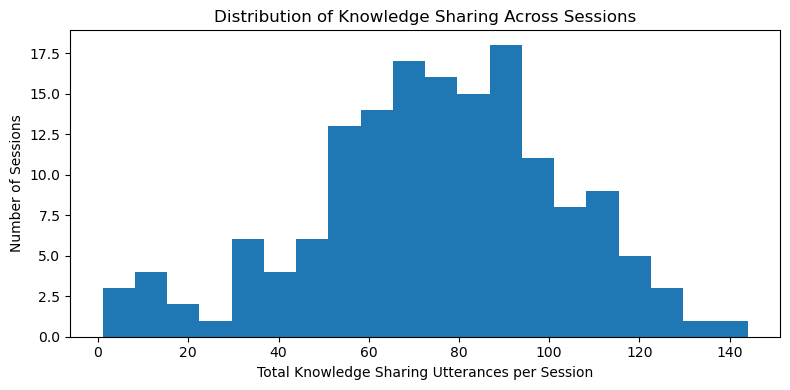

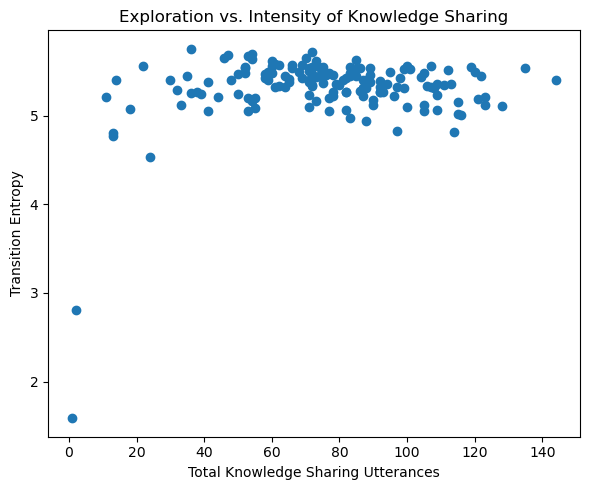

Mean KS_total_utterances by conference:
  conference  mean_KS_total
0    2020NES      35.562500
1    2021ABI      83.840000
2    2021CMC      71.285714
3    2021MND      73.625000
4    2021MZT      64.600000
5    2021NES      92.166667
6    2021SLU      80.000000
7    2022MND      89.722222


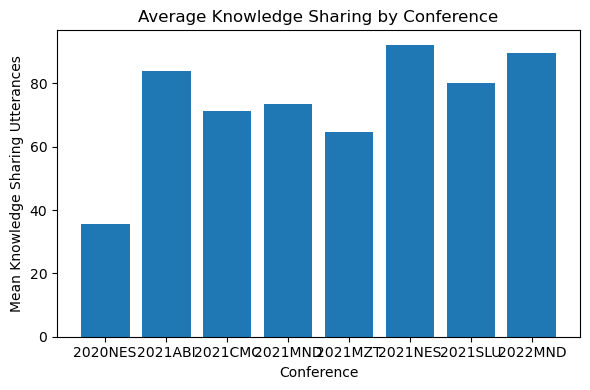

Saved modeling-ready features to:
  /Users/maxchalekson/Desktop/gemini_data_analysis/data/session_linkography_features.csv


In [32]:
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------
# 1. COMPACT SUMMARY TABLE FOR SLIDES
# ---------------------------------------------
# Pick a subset of the 38 columns that tell the clearest story
cols_for_summary = [
    "conference", "session",
    "n_utterances", "n_speakers", "max_time",
    "Beginning", "Middle", "End",
    "Idea_Management", "Information_Seeking", "Knowledge_Sharing",
    "Evaluation_Practices", "Relational_Climate",
    "KS_total_utterances", "KS_streak_count",
    "KS_max_streak_len", "KS_mean_streak_len",
    "KS_first_minute", "KS_last_minute", "KS_mean_minute",
    "n_transitions", "n_unique_pairs", "transition_entropy",
    "KS_to_KS", "KS_to_Idea", "Idea_to_KS",
    "KS_to_Eval", "Eval_to_KS",
    "KS_to_Info", "Info_to_KS",
    "KS_to_Rel", "Rel_to_KS",
]

# Keep only the columns that actually exist (just in case)
cols_for_summary = [c for c in cols_for_summary if c in df_session_linkography.columns]

df_summary = df_session_linkography[cols_for_summary].copy()

# Example: sort by total KS to see the most KS-heavy sessions
df_summary_sorted = df_summary.sort_values("KS_total_utterances", ascending=False)

print("df_summary_sorted (top 10 by total KS):")
print(df_summary_sorted.head(10))

# ---------------------------------------------
# 2. OVERVIEW PLOTS ACROSS ALL SESSIONS
# ---------------------------------------------
plt.figure(figsize=(8, 4))
plt.hist(df_session_linkography["KS_total_utterances"], bins=20)
plt.xlabel("Total Knowledge Sharing Utterances per Session")
plt.ylabel("Number of Sessions")
plt.title("Distribution of Knowledge Sharing Across Sessions")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 5))
plt.scatter(
    df_session_linkography["KS_total_utterances"],
    df_session_linkography["transition_entropy"]
)
plt.xlabel("Total Knowledge Sharing Utterances")
plt.ylabel("Transition Entropy")
plt.title("Exploration vs. Intensity of Knowledge Sharing")
plt.tight_layout()
plt.show()

# If you want to see how KS_total varies by conference:
if "conference" in df_session_linkography.columns:
    mean_ks_by_conf = (
        df_session_linkography
        .groupby("conference")["KS_total_utterances"]
        .mean()
        .reset_index(name="mean_KS_total")
    )
    print("Mean KS_total_utterances by conference:")
    print(mean_ks_by_conf)

    plt.figure(figsize=(6, 4))
    plt.bar(mean_ks_by_conf["conference"], mean_ks_by_conf["mean_KS_total"])
    plt.xlabel("Conference")
    plt.ylabel("Mean Knowledge Sharing Utterances")
    plt.title("Average Knowledge Sharing by Conference")
    plt.tight_layout()
    plt.show()

# ---------------------------------------------
# 3. EXPORT THE MODELING-READY TABLE
# ---------------------------------------------
out_path = "/Users/maxchalekson/Desktop/gemini_data_analysis/data/session_linkography_features.csv"
df_session_linkography.to_csv(out_path, index=False)
print(f"Saved modeling-ready features to:\n  {out_path}")